# BioJEPA v0.6 Training Pipeline

In [1]:
import torch
import random
import gc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

from biojepa_v0_6 import BioJepa, BioJepaConfig
from dataloader_v0_6 import PretrainLoader, AlignmentLoader, TrainingLoader
from training_v0_6 import create_model, load_feature_banks, run_pretraining, run_alignment, run_full_training, train_linear_decoder, maybe_compile
from config_v0_6 import PretrainConfig, AlignmentConfig, FullTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_pretraining_evals, run_alignment_evals, run_full_model_evals, save_report

## Device & Paths

In [2]:
def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(1337)
        device = 'cuda'
    print(f'using {device}')
    return torch.device(device)

torch.manual_seed(1337)
random.seed(1337)
torch.set_float32_matmul_precision('high')

device = get_device()

USE_AMP = torch.cuda.is_available()
USE_COMPILE = torch.cuda.is_available()
USE_FUSED = torch.cuda.is_available()

data_root = Path('/home/ubuntu/data/v0_6')
ref_root = Path('/home/ubuntu/data/reference_data')

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoints',
    ref_dir = ref_root,
    eval_results_dir=data_root / 'eval_results'
)

using cuda


## Hyperparameters

In [3]:
# Model architecture
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer=6,
    heads=4,
    embed_dim=256,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.766,
    gaussian_scale=2.38,
    film_linear_multiple=0.81,
    sim_coeff=40.5,
    std_coeff=40.5,
    cov_coeff=1.62,
    pert_latent_dim= 320,
    pert_mode_dim= 64,
)

# Training configs
pt_cfg = PretrainConfig(epochs=20, lr=1e-4, batch_size=64) 
align_cfg = AlignmentConfig(epochs=1000, lr=4e-3, batch_size=64)
full_cfg = FullTrainingConfig(epochs=10, predictor_lr=1e-4, batch_size=32) 
decoder_cfg = DecoderConfig(epochs=10, lr=1e-3, batch_size=32) 

## Initialize Model & Data

In [4]:
model = create_model(model_cfg, device)
model = maybe_compile(model, USE_COMPILE)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

Loaded DNA embeddings: torch.Size([11643, 1536])
Loaded chemical embeddings: torch.Size([188, 1536])
Loaded target embeddings: torch.Size([9975, 320])
Student/Teacher: 7,979,266
ACpredictor: 10,036,224
PerturbationComposer: 1,478,976


### Load pretraining model from checkpoint (for resuming)

In [5]:
checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v0_6_pt_final.pt'
with torch.serialization.safe_globals([BioJepaConfig]):
    checkpoint = torch.load(checkpoint_path)

keys = model.load_state_dict(checkpoint['model'])
keys

<All keys matched successfully>

## Function to decompress and recompress a directory

In [6]:
def decompress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'decompress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez(tmp_path, **arrays)
        tmp_path.replace(src_path)

def compress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'compress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez_compressed(tmp_path, **arrays)
        tmp_path.replace(src_path)

## Pretraining

In [7]:
# decompress_npz(data_cfg.data_root / 'pretraining')

In [6]:
pt_train_loader = PretrainLoader(
    batch_size=pt_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pretraining', 
    device=device )
pt_val_loader = PretrainLoader(
    batch_size=pt_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pretraining', 
    device=device)

found 1123 shards for split train
shard balancing (threshold=67, 10% of max=668):
  adamson: 22 -> 88 shards (x4)
  k562e_raw: 48 -> 96 shards (x2)
  k562gw: 668 shards
  norman: 39 -> 78 shards (x2)
  rep1e: 80 shards
  sciplex: 266 shards
found 71 shards for split val


In [9]:
pt_results = run_pretraining(model, pt_train_loader, pt_val_loader, pt_cfg, device, data_cfg, model_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED, eval_every_n_epochs=2)

Pretraining: 3266560 samples, 51040 steps/epoch, 1020800 total steps
Step 0 | val loss: 121.4275
Step 0 | Loss: 121.39217 | LR: 4.00e-06
Step 100 | Loss: 104.15513 | LR: 4.00e-06
Step 200 | Loss: 95.32476 | LR: 4.00e-06
Step 300 | Loss: 90.34389 | LR: 4.01e-06
Step 400 | Loss: 86.51820 | LR: 4.01e-06
Step 500 | val loss: 84.2261
Step 500 | Loss: 84.19189 | LR: 4.02e-06
Step 600 | Loss: 83.78852 | LR: 4.03e-06
Step 700 | Loss: 81.25115 | LR: 4.04e-06
Step 800 | Loss: 80.26144 | LR: 4.06e-06
Step 900 | Loss: 77.73820 | LR: 4.07e-06
Step 1000 | val loss: 74.1098
Step 1000 | Loss: 73.24789 | LR: 4.09e-06
Step 1100 | Loss: 70.61324 | LR: 4.11e-06
Step 1200 | Loss: 70.00600 | LR: 4.13e-06
Step 1300 | Loss: 68.57922 | LR: 4.15e-06
Step 1400 | Loss: 67.17686 | LR: 4.18e-06
Step 1500 | val loss: 72.0174
Step 1500 | Loss: 66.05977 | LR: 4.20e-06
Step 1600 | Loss: 66.59451 | LR: 4.23e-06
Step 1700 | Loss: 68.45469 | LR: 4.26e-06
Step 1800 | Loss: 65.33620 | LR: 4.29e-06
Step 1900 | Loss: 65.25463

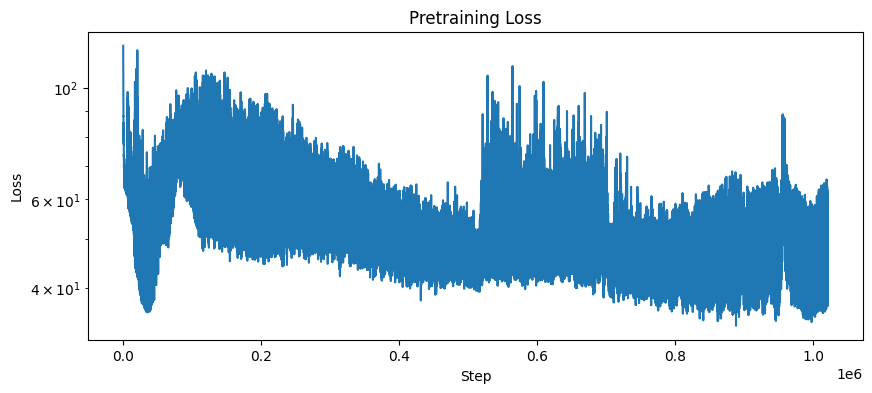

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Pretraining Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [11]:
if pt_results['epoch_evals']:
    evals_df = pd.DataFrame({e: d['metrics'] for e, d in pt_results['epoch_evals'].items()}).T
    evals_df.index = evals_df.index.astype(int)
    evals_df.index.name = 'epoch'
    evals_df.sort_index()

### Pretraining Evals

In [7]:
eval_ctx = EvalContext.from_trained_model(model, decoder=None, data_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim, 
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': pt_cfg.batch_size
})
pt_eval_results = run_pretraining_evals(eval_ctx)

save_report(pt_eval_results, data_cfg.eval_results_dir / 'pretraining_eval_report.json')
pt_eval_results

Using cuda
found 121 shards for split test


batch_invariance: Extracting embeddings: 100%|████████████████████████████████| 606/606 [00:53<00:00, 11.42it/s]


Training batch classifier...
Training perturbation classifier...
batch_invariance: Batch=0.0718 (26.4x), Pert=0.0914 (97.6x)
Loading KEGG_2021_Human...
  320 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
gene_embedding_pathways: KEGG sil=-0.0716, Reactome sil=-0.0830
essential_gene_prediction: Pearson=0.2211, AUROC=0.6293
found 121 shards for split test


cell_type_probing: Extracting embeddings: 100%|███████████████████████████████| 606/606 [00:44<00:00, 13.51it/s]


Training cell type classifier...
cell_type_probing: Accuracy=0.9972 (2.0x chance), Macro F1=0.9884
found 121 shards for split test


...

embedding_consistency: Extracting embeddings: 100%|███████████████████████████| 606/606 [00:45<00:00, 13.46it/s]


embedding_consistency: Intra=16.9935, Inter=14.4746, Ratio=0.85x
found 121 shards for split test


latent_space_health: Extracting embeddings: 100%|█████████████████████████████| 606/606 [00:44<00:00, 13.50it/s]


latent_space_health: Eff_dim_90=42/256, Mean_var=0.4933, Isotropy=0.000066
Saved report to /home/ubuntu/data/v0_6/eval_results/pretraining_eval_report.json


{'batch_invariance': {'config': {'samples': 38784,
   'embedding_dim': 256,
   'num_batches': 367,
   'num_perturbations': 1068},
  'batch_classifier': {'accuracy': 0.07180611060977182,
   'chance': 0.0027247956403269754,
   'above_chance_ratio': 26.35284259378626},
  'perturbation_classifier': {'accuracy': 0.0914013149413433,
   'chance': 0.0009363295880149813,
   'above_chance_ratio': 97.61660435735465},
  'invariance_ratio': 1.272890484739677},
 'gene_embedding_pathways': {'config': {'n_genes': 10000},
  'kegg': {'silhouette_score': -0.07157112658023834,
   'knn_accuracy': 0.03713961531626362,
   'knn_std': 0.005626330396685389,
   'n_classes': 122,
   'n_samples': 3312},
  'reactome': {'silhouette_score': -0.08298886567354202,
   'knn_accuracy': 0.02673252819892008,
   'knn_std': 0.0066740774044187524,
   'n_classes': 167,
   'n_samples': 4564}},
 'essential_gene_prediction': {'config': {'matched_genes': 9055,
   'train_genes': 7244,
   'test_genes': 1811},
  'regression': {'pearso

In [8]:
# compress_npz(data_cfg.data_root / 'pretraining')

In [9]:
del pt_train_loader, pt_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Stage 2: Perturbation Alignment

In [6]:
align_train_loader = AlignmentLoader(
    batch_size=align_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device, total_samples=1250)
align_val_loader = AlignmentLoader(
    batch_size=align_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

found 1 shards for split train
found 1 shards for split val


In [7]:
align_results = run_alignment(model, align_train_loader, align_val_loader, seq_banks, target_bank, align_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

Alignment: 1250 samples, 19 steps/epoch, 19000 total steps
Step 0 | val loss: 4.3552
Step 0 | Loss: 4.37463 | LR: 1.60e-04
Step 100 | Loss: 3.94777 | LR: 2.66e-04
Step 200 | Loss: 4.02124 | LR: 5.70e-04
Step 300 | Loss: 3.92939 | LR: 1.04e-03
Step 400 | Loss: 3.92548 | LR: 1.62e-03
Step 500 | val loss: 3.5607
Step 500 | Loss: 3.88867 | LR: 2.25e-03
Step 600 | Loss: 4.09131 | LR: 2.86e-03
Step 700 | Loss: 4.08398 | LR: 3.39e-03
Step 800 | Loss: 3.93824 | LR: 3.77e-03
Step 900 | Loss: 3.89270 | LR: 3.98e-03
Step 1000 | val loss: 3.5480
Step 1000 | Loss: 3.95338 | LR: 4.00e-03
Step 1100 | Loss: 3.95380 | LR: 4.00e-03
Step 1200 | Loss: 4.01868 | LR: 4.00e-03
Step 1300 | Loss: 3.98328 | LR: 4.00e-03
Step 1400 | Loss: 3.95179 | LR: 3.99e-03
Step 1500 | val loss: 3.5666
Step 1500 | Loss: 4.01727 | LR: 3.99e-03
Step 1600 | Loss: 4.06299 | LR: 3.99e-03
Step 1700 | Loss: 4.06982 | LR: 3.98e-03
Step 1800 | Loss: 4.02417 | LR: 3.98e-03
Step 1900 | Loss: 4.00464 | LR: 3.97e-03
Step 2000 | val loss:

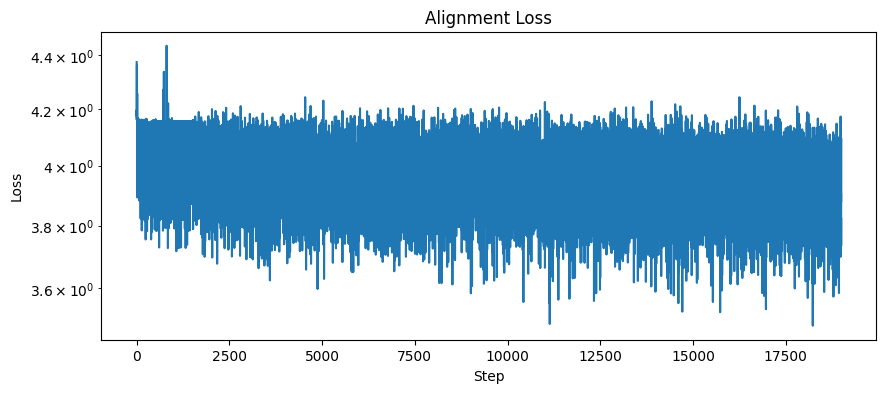

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Alignment Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Alignment Evals

In [9]:
align_eval_ctx = EvalContext.from_trained_model(model, decoder=None, data_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': align_cfg.batch_size
})
align_eval_results = run_alignment_evals(align_eval_ctx)

save_report(align_eval_results, data_cfg.eval_results_dir / 'alignment_eval_report.json')
align_eval_results

Using cuda
Loaded 10797 v0.6 alignment pairs
Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1536])
Encoded DNA sequences: torch.Size([11643, 320])
Encoded chemical sequences: torch.Size([188, 320])
Loaded target bank: torch.Size([9975, 320])
Encoded protein targets: torch.Size([9975, 320])
seq_to_target_retrieval: dna_mrr=0.0015
cross_modality_target_consistency: Within=0.9007, Between=0.8746, Ratio=1.03x
seq_target_gap_analysis: dna_gap=2.11
paired_alignment_quality: dna_sim=0.7763
mode_sensitivity: Classification_acc=0.9262 (6.5x chance)
fusion_quality: Fused_var=3.5414, Seq_var=3.3712, Target_var=0.0683
missing_data_robustness: Fused_MRR=0.0048, Seq_only=0.0045, Target_only=0.9975
found 121 shards for split test


multi_pert_alignment: Scanning for multi-pert: 100%|█████████████████████████| 500/500 [00:03<00:00, 130.34it/s]


Loaded 27264 HGNC gene family annotations
target_family_probing: seq_only=0.0590, target_only=0.1704, fused=0.0901
Saved report to /home/ubuntu/data/v0_6/eval_results/alignment_eval_report.json


{'seq_to_target_retrieval': {'config': {'n_targets': 9975},
  'by_modality': {'dna': {'mrr': 0.0015144257840032384,
    'median_rank': 4599.0,
    'mean_rank': 4707.445677734926,
    'n_queries': 10631,
    'n_targets': 9975,
    'recall_at_k': {'1': 9.406452826639074e-05,
     '5': 0.0009406452826639074,
     '10': 0.0023516132066597685,
     '20': 0.004232903771987584,
     '50': 0.00893613018530712}}}},
 'cross_modality_target_consistency': {'config': {'n_valid_targets': 915,
   'n_within_pairs': 1452,
   'n_between_pairs': 5000},
  'metrics': {'within_target_sim': 0.9007055759429932,
   'between_target_sim': 0.8745984373316169,
   'consistency_ratio': 1.0298504290620831}},
 'seq_target_gap_analysis': {'target_variance': 21.59844398498535,
  'n_targets': 9975,
  'dna': {'seq_variance': 1189.5548095703125,
   'centroid_distance': 82.21728515625,
   'mean_within_seq': 41.57221603232424,
   'mean_seq_to_target': 87.78388214111328,
   'gap_ratio': 2.1115997779107425,
   'n_sequences': 1

In [10]:
del align_train_loader, align_val_loader, align_eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Stage 3: Full Training

In [11]:
train_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'training', 
    device=device)
val_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'training', 
    device=device)

full_results = run_full_training(model, train_loader, val_loader, seq_banks, target_bank, full_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 976 shards for split train
shard balancing (threshold=65, 10% of max=643):
  adamson: 21 -> 84 shards (x4)
  k562e_raw: 48 -> 96 shards (x2)
  k562gw: 643 shards
  norman: 16 -> 80 shards (x5)
  sciplex: 248 shards
found 62 shards for split val
Full training: 2946560 samples, 92080 steps/epoch, 920800 total steps
Step 0 | val loss: 154.4341
Step 0 | Loss: 138.71977 | LR: 4.00e-06
Step 100 | Loss: 125.54780 | LR: 4.00e-06
Step 200 | Loss: 97.29317 | LR: 4.00e-06
Step 300 | Loss: 88.37917 | LR: 4.01e-06
Step 400 | Loss: 96.80699 | LR: 4.02e-06
Step 500 | val loss: 92.9308
Step 500 | Loss: 88.88211 | LR: 4.03e-06
Step 600 | Loss: 91.47040 | LR: 4.04e-06
Step 700 | Loss: 93.32484 | LR: 4.05e-06
Step 800 | Loss: 88.63077 | LR: 4.07e-06
Step 900 | Loss: 86.90513 | LR: 4.09e-06
Step 1000 | val loss: 89.1380
Step 1000 | Loss: 86.18387 | LR: 4.11e-06
Step 1100 | Loss: 89.68437 | LR: 4.14e-06
Step 1200 | Loss: 86.19215 | LR: 4.16e-06
Step 1300 | Loss: 88.93042 | LR: 4.19e-06
Step 1400 | Lo

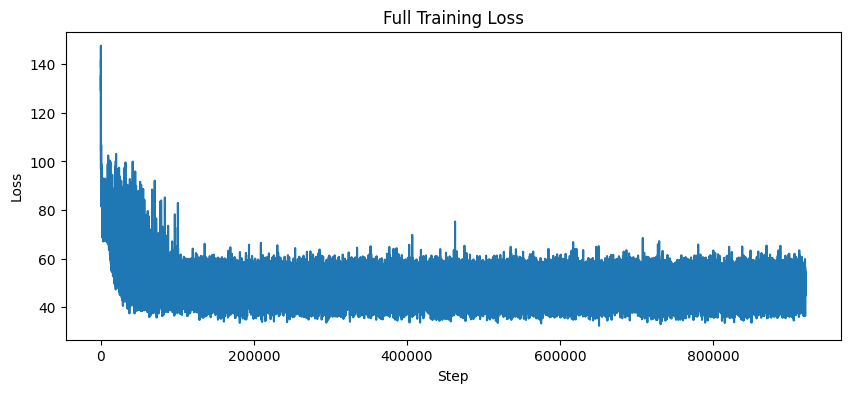

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('Full Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [13]:
del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Linear Decoder Training

In [14]:
decoder_train_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'training', 
    device=device, 
    total_samples=101682)
decoder_val_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size,
    split='val', data_dir=data_cfg.data_root / 'training',
    device=device,
    total_samples=11044)

decoder, decoder_results = train_linear_decoder(model, decoder_train_loader, decoder_val_loader, seq_banks, target_bank, model_cfg, device, data_cfg.checkpoint_dir, decoder_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 976 shards for split train
shard balancing (threshold=65, 10% of max=643):
  adamson: 21 -> 84 shards (x4)
  k562e_raw: 48 -> 96 shards (x2)
  k562gw: 643 shards
  norman: 16 -> 80 shards (x5)
  sciplex: 248 shards
found 62 shards for split val
Decoder Step 0 | val loss: 2.1909
Decoder Step 0 | Loss: 1.81443
Decoder Step 100 | Loss: 2.24387
Decoder Step 200 | Loss: 1.62875
Decoder Step 300 | Loss: 1.06852
Decoder Step 400 | Loss: 0.79010
Decoder Step 500 | val loss: 0.5934
Decoder Step 500 | Loss: 1.13888
Decoder Step 600 | Loss: 0.59185
Decoder Step 700 | Loss: 0.25172
Decoder Step 800 | Loss: 0.17256
Decoder Step 900 | Loss: 0.42431
Decoder Step 1000 | val loss: 0.1578
Decoder Step 1000 | Loss: 0.15850
Decoder Step 1100 | Loss: 0.13196
Decoder Step 1200 | Loss: 0.12243
Decoder Step 1300 | Loss: 0.13858
Decoder Step 1400 | Loss: 0.14893
Decoder Step 1500 | val loss: 0.1771
Decoder Step 1500 | Loss: 0.35218
Decoder Step 1600 | Loss: 0.14435
Decoder Step 1700 | Loss: 0.14637
Decod

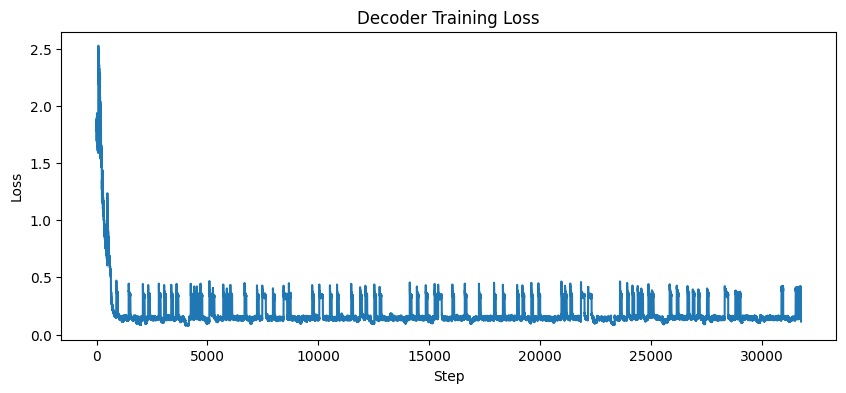

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(decoder_results['loss_history'])
plt.title('Decoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## Full Model Evals

In [16]:
eval_ctx = EvalContext.from_trained_model(model, decoder=decoder, data_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': full_cfg.batch_size
})
full_eval_results = run_full_model_evals(eval_ctx)

save_report(full_eval_results, data_cfg.eval_results_dir / 'full_model_eval_report.json')
full_eval_results

Using cuda
found 121 shards for split test


Running test inference:   0%|                                                          | 0/1213 [00:00<?, ?it/s]

Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1536])
Loaded target bank: torch.Size([9975, 320])


Running test inference:   2%|█▏                                               | 30/1213 [00:17<02:46,  7.12it/s]/home/ubuntu/code/biojepa/evals/evals.py:397: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(p_top, t_top)
Running test inference: 100%|███████████████████████████████████████████████| 1213/1213 [03:07<00:00,  6.46it/s]


Aggregated 1073 perturbations, 38816 samples
expression_prediction: MSE=0.2269, R2_all=0.9317
gene_level_analysis: Dir_acc=0.9342, Top50_acc=0.2911


perturbation_retrieval (dna): 100%|█████████████████████████████████████████| 100/100 [1:16:41<00:00, 46.02s/it]


perturbation_retrieval (dna): MRR=0.0004


perturbation_retrieval (chemical): 100%|████████████████████████████████████████| 13/13 [00:09<00:00,  1.36it/s]


perturbation_retrieval (chemical): MRR=0.0348
uncertainty_calibration: ECE=0.5202, Monotonicity=22.22%
Loading KEGG_2021_Human...
  320 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
Encoded DNA sequences: torch.Size([11643, 320])
Encoded chemical sequences: torch.Size([188, 320])
Encoded protein targets: torch.Size([9975, 320])
action_vector_pathways DNA: sil=-0.33890336751937866
Loaded 10797 v0.6 alignment pairs
moa_matching: Within=0.5108, Between=0.4692, Ratio=1.089x
Saved report to /home/ubuntu/data/v0_6/eval_results/full_model_eval_report.json


{'expression_prediction': {'config': {'test_perturbations': 1073,
   'genes': 10000,
   'test_samples': 38816},
  'sample_level': {'mse': 0.2269037812948227,
   'pearson_r_top20': 0.8719303749309951},
  'perturbation_level': {'r2_all_genes': {'mean': 0.9317425161127942,
    'median': 0.9450898766517639},
   'r2_top50_degs': {'mean': 0.4418776113633674, 'median': 0.5132589936256409},
   'mse': {'mean': 0.01509273424744606, 'median': 0.011855305172502995}},
  'severity': {'pearson_r': 0.968832790851593,
   'spearman_r': 0.927201136434899},
  'error_by_magnitude': {'0-0.25': {'mae': 0.07882104068994522,
    'count': 10128965},
   '0.25-0.5': {'mae': 0.20794089138507843, 'count': 521116},
   '0.5-1.0': {'mae': 0.389729768037796, 'count': 70933},
   '1.0-1.5': {'mae': 0.6826462149620056, 'count': 7778},
   '1.5-2.0': {'mae': 1.0758830308914185, 'count': 994},
   '2.0+': {'mae': 1.5696572065353394, 'count': 214}}},
 'gene_level_analysis': {'config': {'test_perturbations': 1073,
   'genes': 1

In [17]:
del decoder_train_loader, decoder_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Summary

In [18]:
print('=== Training Complete ===')
print(f'Pretraining final loss: {pt_results["final_loss"]:.5f}')
print(f'Alignment final loss: {align_results["final_loss"]:.5f}')
print(f'Full training final loss: {full_results["final_loss"]:.5f}')
print(f'Decoder final loss: {decoder_results["final_loss"]:.5f}')
print(f'\nCheckpoints saved to: {data_cfg.checkpoint_dir}')
print(f'Eval reports saved to: {data_cfg.eval_results_dir}')

=== Training Complete ===


NameError: name 'pt_results' is not defined